# Decentralized Model

This is a version of the model where the central bank and the government make decisions taken as given the actions of the other. That is, we need to establish the best responses of each agent, and then find the potential equilibriums.

The central bank chooses F which is the source of the credit or liquidity policy.

The government chooses DLA which is the size of the stabilization  SWF, that indirectly determines the amount of resources available to transfer in the long run (We assume that s1 is equal to zero, that means that there is no reason to have liquid assets  from t1 to t2).

# Centralized Model

This is a version of the model where the central bank and the government make decisions together. The general government chooses the stock of liquid assets versus the long-run project first. Then, given the amopunt of liquid assets, it chooses whether to use it as reserves (lend to banks) or transfers to households.





In [1]:
# Import packages
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")
import time

from functools import partial
import jax
import jax.numpy as jnp
from jax import lax
from jax import vmap
from jax import jit
import matplotlib.pyplot as plt
import numpy as np  
from collections import namedtuple
from scipy.optimize import fsolve
jax.config.update("jax_enable_x64", True)

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

In [34]:

Model = namedtuple(
    "Model",
    (
        "α", "σ", "γ", "τ", "τg","τlt", "β", "ρ", "Rstar", "s", "N", "T", "Z",
        "θ_l", "θ_h", "Fgrid", "θgrid", "g0", "g1", "g2", "A",
        "F_l", "F_h", "θ_grid", "F_grid", "Π", "Rbar",
        "Bgrid", "Sgrid", "B_l", "B_h", "κ"
    )
)

def create_model(
    α: float = 0.8,
    σ: float = 2.0,
    γ: float = 0.5,
    τ: float = 0.04,
    τg: float = 0.04,
    τlt: float = 0.02,
    β: float = 0.95,
    ρ: float = 2.0,
    Rstar: float = 1.0,
    s: float = 1.4,
    N: float = 1.0,
    T: float = 0.2,
    Z: float = 2.0,
    θ_l: float = 0.4,
    θ_h: float = 0.7,
    Fgrid: int = 100,
    Sgrid: int = 100,
    Bgrid: int = 100,
    θgrid: int = 100,
    g0: float = 0.4,
    g1: float = 0.4,
    g2: float = 0.4,
    A: float  = 0.2,
    F_l: float = 0.0,
    F_h: float = 2.0,
    B_l: float = 0.0,
    B_h: float = 2.0,
) -> Model:
    # r is unused, so I'm omitting it; re-add if you'll use it downstream
    # r = (s - 1) / s

    # JAX arrays for grids and probabilities
    κ = 1.0 / (γ**γ * (1.0 - γ)**(1.0 - γ))
    θ_grid = jnp.linspace(θ_l, θ_h, θgrid, dtype=jnp.float64)
    F_grid = jnp.linspace(F_l, F_h, Fgrid, dtype=jnp.float64)
    
    # Uniform probabilities over θ_grid
    nθ = θ_grid.size
    Π  = jnp.ones(nθ, dtype=jnp.float64) / nθ

    Rbar = Rstar * Rstar * τlt

    return Model(α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ)


# If you want to print the model parameters for verification:

def print_model_parameters(model):
    """
    Print all parameters of a Model namedtuple in a readable format.
    
    Args:
        model: Model namedtuple containing all model parameters
    """
    print("Model Configuration:")
    print("=" * 60)
    for i, field_name in enumerate(Model._fields):
        value = getattr(model, field_name)
        print(f"{i:2d}  {field_name:15s}   ->  {value}")
    print("=" * 60)



In [35]:
def successive_approx(K, v_init, max_iter: int = 50_000, tol: float = 1e-12):
    """
    Compute a fixed point of K by iterating from guess v_init.

    This version is JAX-friendly: it uses lax.while_loop and jnp, so it can be jit-compiled.
    """

    def cond_fun(state):
        v, i, error = state
        return jnp.logical_and(error > tol, i < max_iter)

    def body_fun(state):
        v, i, _ = state
        v_new = K(v)
        error = jnp.max(jnp.abs(v_new - v))
        return (v_new, i + 1, error)

    # Start with "infinite" error so we always do at least one iteration
    init_state = (v_init, 0, jnp.inf)
    v_final, iters, _ = lax.while_loop(cond_fun, body_fun, init_state)
    return v_final, iters


def newton_solver(K, v_init, max_iter: int = 50_000, tol: float = 1e-10):
    """
    Apply Newton's method to find a root of K(v) = 0.

    We iterate with:
        Q(v) = v - J(v)^{-1} K(v),
    where J(v) is the Jacobian of K at v.

    Implemented in a JAX-friendly way so you can jit it or differentiate through it.
    """
    # Precompute the Jacobian function once
    J = jax.jacobian(K)

    def Q(v):
        return v - jnp.linalg.solve(J(v), K(v))

    return successive_approx(Q, v_init, max_iter=max_iter, tol=tol)

In [36]:
# Model Specific Functions

def financial_constraint(v, consumption, liquid, reserves, model):
    """
    Given a candidate for the interest rate in period 1, compute the value of the
    financial constraint in the model. JAX-friendly version (uses jnp only).

    Args: 
        v:        vector of interest rates in period 1 (shape (θgrid,))
        consumption: scalar consumption in period 0 (Chat)
        liquid:   tuple (DLA, s1)
        reserves: scalar reserves policy in period 1 (F)
        model:    Model namedtuple with JAX-compatible arrays / scalars
    """
    
    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model
    
    R1 = v
    Chat = consumption
    DLA, s1 = liquid
    F = reserves
    
    # Tax burden between t=0 and t=1
    tb = Rstar * g0 + g1 - Rstar * DLA + s1 

    # Lending conditional on interest rate
    L = ((α * Z / R1) * (N / γ) ** (α * γ)) ** (1.0 / (1.0 - α * (1.0 - γ)))

    # Demand for tradable inputs in capital production
    I = (1.0 - γ) * L

    # Optimal capital
    K_cap = κ * (N ** γ) * (I ** (1.0 - γ))

    # Price of capital and exchange rate
    Q = L / K_cap
    X = Q ** (1.0 / γ)
    
    # Value of collateral / constraint term (vector over θ_grid)
    V = (Rstar / (Rstar - (1.0 - θ_grid) * R1)) * (T + X * N + Rstar * F) - (Rstar * Chat + L + tb)
    return V


def ramsey_constraint(v, consumption, liquid, model):
    """
    Given a candidate for the interest rate in period 1, compute the value of the
    financial constraint in the Ramsey model (JAX-friendly version).

    Args:
        v:          vector of interest rates in period 1 (shape (θgrid,))
        consumption: scalar consumption in period 0 (Chat)
        liquid:     tuple (DLA, f) where DLA is liquid assets t0→t1 and f is
                    the one-period Ramsey asset (or policy variable)
        model:      Model namedtuple with JAX-compatible arrays / scalars
    """

    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model

    R1   = v
    Chat = consumption
    DLA, f = liquid

    # Tax burden term
    tb = Rstar * g0 + g1 - (Rstar * DLA - f)

    # Lending conditional on interest rate
    L = ((α * Z / R1) * (N / γ) ** (α * γ)) ** (1.0 / (1.0 - α * (1.0 - γ)))

    # Demand for tradable inputs in capital production
    I = (1.0 - γ) * L

    # Optimal capital
    K_cap = κ * (N ** γ) * (I ** (1.0 - γ))

    # Price of capital and exchange rate
    Q = L / K_cap
    X = Q ** (1.0 / γ)

    # Value of the Ramsey financial constraint (vector over θ_grid)
    V = (Rstar / (Rstar - (1.0 - θ_grid) * R1)) * (T + X * N + f) - (Rstar * Chat + L + tb)

    return V

def welfare(λ, Ufb, C, EC, model):
    """
    λ      : Lucas constant (scalar, can be jnp.array or Python float)
    Ufb    : welfare in the frictionless benchmark (scalar)
    C      : consumption at t=0 (scalar)
    EC     : expected value of consumption in t=1 (scalar)
    model  : Model namedtuple with at least σ and β
    """
    σ = model.σ
    β = model.β

    λ = jnp.asarray(λ)
    C = jnp.asarray(C)
    EC = jnp.asarray(EC)
    Ufb = jnp.asarray(Ufb)

    term1 = (C * (1.0 + λ)) ** (1.0 - σ) / (1.0 - σ)
    term2 = β * EC * (1.0 + λ)

    V = term1 + term2 - Ufb
    return V  

def values_old(consumption, fiscal, reserves, Ufb, model):

    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model
    Chat = consumption
    B, DLA, s1 = fiscal
    F = reserves
    liquid = (DLA, s1)

    # --------------------------------------------
    # 1. Solve for R₁(θ) using JAX Newton solver
    # --------------------------------------------
    v_init = jnp.ones((θgrid,))

    def Fc(z):
        return financial_constraint(z, Chat, liquid, reserves, model)

    v_newton, _ = newton_solver(Fc, v_init)
    R1 = jnp.maximum(Rstar, v_newton)

    # --------------------------------------------
    # 2. Factor prices and allocations (state-contingent)
    # --------------------------------------------
    L = ((α * Z / R1) * (N / γ)**(α * γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
    I = (1.0 - γ) * L

    K_cap = κ * (N**γ) * (I ** (1.0 - γ))

    Q = L / K_cap
    X = Q ** (1.0 / γ)

    tb = -Rstar*DLA + s1 + Rstar*g0 + g1

    Cs = Z*K_cap**α - Rstar*I + Rstar*T - (Rstar**2)*Chat - (Rstar**2)*g0 - Rstar*g1 - g2 - τ*(Rstar**2)*F + (τlt - τg)*(Rstar**2)*B - τlt*(Rstar**2)*DLA + (Rstar**2)*A

    EC = jnp.sum(Cs * Π)
    ER = jnp.sum(R1 * Π)

    grids = (R1, L, K_cap, Q, X, Cs)

    # --------------------------------------------
    # 3. Optimal values (aggregate)
    # --------------------------------------------
    Ls = ((α * Z / ER) * (N / γ)**(α*γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
    Is = (1.0 - γ) * Ls
    Ks = κ * (N**γ) * (Is ** (1.0 - γ))
    Qs = Ls / Ks
    Xs = Qs ** (1.0 / γ)

    θhat = (T + Xs * N + Rstar * F) / (Rstar * Chat + Ls + tb)

    optimal_values = (Chat, ER, EC, Ls, Is, Ks, Qs, Xs, θhat)

    # --------------------------------------------
    # 4. JAX Newton solver for λ in welfare equation
    #    (replaces SciPy fsolve)
    # --------------------------------------------

    def welfare_root(λ):
        return welfare(λ, Ufb, Chat, EC, model)    # must return scalar jnp.float_

    # Use scalar Newton (via your newton_solver) — wrap λ as length-1 vector
    λ_init = jnp.array([0.0])

    λ_vec, _ = newton_solver(
        lambda z: jnp.array([welfare_root(z[0])]),
        λ_init
    )

    λ_star = λ_vec[0]

    return (grids, optimal_values, λ_star)

def values(R1, consumption, B, DLA, reserves, model, s1):

    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model

    C0 = consumption
    Fhat = reserves
    
    # --------------------------------------------
    # State-contingent factor prices and allocations
    # --------------------------------------------
    
    Ls = ((α * Z / R1) * (N / γ)**(α*γ)) ** (1.0 / (1.0 - α*(1.0-γ)))
    Is = (1.0 - γ) * Ls
    Ks = κ * (N**γ) * (Is ** (1.0 - γ))
    Qs = Ls / Ks
    Xs = Qs ** (1.0 / γ)
    
    tb = -Rstar * DLA + s1 + Rstar * g0 + g1

    Cs = Z * Ks**α + Rstar * (Is - T)  - (Rstar**2) * C0 - (Rstar**2) * g0 - Rstar * g1 - g2 - τ * (Rstar**2) * Fhat + (τlt - τg) * (Rstar**2) * B - τlt * (Rstar**2) * DLA + (1.0 + τlt) * (Rstar**2) * A


    return (Ls, Is, Ks, Qs, Xs, tb, Cs)


In [37]:
# Frictionless - Benchmark Model

def frictionless_model(model):
    """Frictionless model: Solves the social planner's problem in the absence of frictions.
    
    Args:
        model _tuple_: Deep parameters of the model

    Returns:
        _vector_: Optimal values for consumption, lending, investment, capital, price of capital, exchange rate, and consumption in t=2
    """
    
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    F = 0 # There are no reserves in the frictionless model
    G = 0 # There are no government expenditures in the frictionless model
    τ2 = 0 # There are no taxes and no debt
    
    C0star = (β * Rstar*Rstar)**(1/-σ) # Optimal consumption
    L = ((α*Z/Rstar)*(N/γ)**(α*γ))**(1/(1-α*(1-γ))) # Optimal lending in the absence of frictions
    I = (1-γ)*L # Optimal demand for tradable inputs in capital production
    κ = 1/(γ**γ*(1 - γ)**(1 - γ)) # Constant for Cobb-Douglas aggregator
    K = (κ)*(N**γ) * (I**(1- γ)) # Optimal capital
    mgnPr = (α)*Z*K**(α-1) # Marginal product of capital
    Q = L/K # Price of capital
    X = Q**(1/γ) # Exchange rate
    C = Z*K**α - Rstar*I + Rstar*T - Rstar*Rstar*C0star - τ*Rstar*Rstar*F - Rstar*G - τ2 # Optimal consumption in t=2
    Y = Z*K**α # Output
    Ufb = C0star**(1-σ )/(1-σ ) + β *C


    
    return C0star, L, I, K, Q, X, C, Ufb, mgnPr, Y

In [38]:
def laissez_faire(Ufb, model, max_iter: int = 50_000, tol: float = 1e-10):
    """
    Laissez-faire model: Solves the decentralized solution in the presence of 
    fiscal policy and financial frictions. No SWF and no reserves policy.

    Args:
        K: Operator function that updates consumption
        Ufb: Welfare in the frictionless benchmark
        model: Model namedtuple with all parameters
        
    Returns:
        grids: State-contingent allocations and prices
        optimal_values: Aggregate allocations
        λ_star: Welfare loss
    """
    # Unpack model parameters
    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model

    # Set fiscal policy: no debt, no SWF, no transfers between periods
    B = 0.0
    DLA = 0.0
    s1 = 0.0
    A=0.0
        
    # Set reserves policy: no reserves
    Fhat = 0.0
    
    liquid = (DLA, s1)

    # State = (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)
    Chat0   = jnp.array(1.0)
    error0  = jnp.inf
    it0     = 0
    zero_vec = jnp.zeros((θgrid,))
    zero_scalar = 0.0

    state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)

    def cond_fun(state):
        Chat, error, it, *_ = state
        return jnp.logical_and(error > tol, it < max_iter)

    def body_fun(state):
        (Chat, _error, it, _R1, _Ls, _Ks, _Qs, _Xs, _Is, _Cs, _ECs, _ERs, _U) = state

        C0 = Chat
        v_init = jnp.ones((θgrid,))
        def Fc(z):
            return financial_constraint(z, C0, liquid, Fhat, model)

        v_newton, _ = newton_solver(Fc, v_init)
        R1 = jnp.maximum(Rstar, v_newton)
        R1 = jnp.minimum(Rstar/(1 - θ_h), R1)  # Cap interest rates to avoid numerical issues

        # Production block
        Ls = ((α * Z / R1) * (N / γ)**(α*γ)) ** (1.0 / (1.0 - α*(1.0-γ)))
        Is = (1.0 - γ) * Ls
        Ks = κ * (N**γ) * (Is ** (1.0 - γ))
        Qs = Ls / Ks
        Xs = Qs ** (1.0 / γ)

        # tb = Tax burden (not explicitly used in Cs here, but kept for clarity)
        tb = -Rstar * DLA + s1 + Rstar * g0 + g1

        Cs = Z * Ks**α + Rstar * T - Rstar * Is  - (Rstar**2) * C0 - (Rstar**2) * g0 - Rstar * g1 - g2 - τ * (Rstar**2) * Fhat + (τlt - τg) * (Rstar**2) * B - τlt * (Rstar**2) * DLA + (1.0 + τlt) * (Rstar**2) * A
            
        ECs = jnp.sum(Cs * Π)
        ERs = jnp.sum(R1 * Π)

        Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)
        error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)
        
        U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs
            

        return (Chat_new, error, it + 1, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

    (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

    return (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)



In [39]:
def decentralizedgov_model(fiscal, reserves, model, max_iter=1_000, tol=1e-10):
    """
    - Uses lax.scan over DLA grid
    - Uses lax.while_loop for inner consumption fixed point
    """

    # Unpack model
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    B, s1 = fiscal
    Fhat = reserves

    DLA_grid = jnp.linspace(0.0, A + B, Sgrid)

    # ------------------------------------------------------
    # scan body: f(carry, x) -> (carry, y)
    #   carry: we don't use it (None)
    #   x:     DLA scalar
    #   y:     tuple of outputs for this DLA
    # ------------------------------------------------------
    def solve_for_DLA(carry, DLA):

        liquid = (DLA, s1)

        # State = (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)
        Chat0   = jnp.array(1.0)
        error0  = jnp.inf
        it0     = 0
        zero_vec = jnp.zeros((θgrid,))
        zero_scalar = 0.0

        state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)

        def cond_fun(state):
            Chat, error, it, *_ = state
            return jnp.logical_and(error > tol, it < max_iter)

        def body_fun(state):
            (Chat, _error, it, _R1, _Ls, _Ks, _Qs, _Xs, _Is, _Cs, _ECs, _ERs, _U) = state

            C0 = Chat
            v_init = jnp.ones((θgrid,))

            def Fc(z):
                return financial_constraint(z, C0, liquid, Fhat, model)

            v_newton, _ = newton_solver(Fc, v_init)
            R1 = jnp.maximum(Rstar, v_newton)
            R1 = jnp.minimum(Rstar/(1 - θ_h), R1)  # Cap interest rates to avoid numerical issues
            
            grids = values(R1, C0, B, DLA, Fhat, model, s1)
            
            (Ls, Is, Ks, Qs, Xs, tb, Cs) = grids

            
            ECs = jnp.sum(Cs * Π)
            ERs = jnp.sum(R1 * Π)

            Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)

            error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)

            U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs

            return (Chat_new, error, it + 1, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

        (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

        # Check convergence and validity
        converged = error <= tol
        has_negative = jnp.any(Cs < 0.0)
        
        # Store convergence info in carry for later checking
        convergence_info = (DLA, converged, has_negative, it, error)
        
        # y has same structure at each DLA; scan will stack along axis 0
        y = (Chat, U, ECs, ERs, R1, Ls, Ks, Qs, Xs, Is, Cs, convergence_info)
        return carry, y

    # Run scan over DLA_grid
    _, results = lax.scan(solve_for_DLA, None, DLA_grid)

    (C0star, Uhat, EC, ER, Spread, L_arr, K_arr, Q_arr, X_arr, I_arr, C2_arr, convergence_info) = results
    
    # Check for convergence failures
    DLA_vals, converged, has_negative, iterations, errors = convergence_info
    
    failed_convergence = jnp.logical_not(converged)
    has_negative_consumption = has_negative
    
    # Collect diagnostic info
    n_failed_convergence = jnp.sum(failed_convergence)
    n_negative_consumption = jnp.sum(has_negative_consumption)
    
    diagnostics = {
        'n_failed_convergence': n_failed_convergence,
        'n_negative_consumption': n_negative_consumption,
        'failed_convergence': failed_convergence,  # Boolean array instead of indices
        'has_negative': has_negative_consumption,  # Boolean array instead of indices
        'max_iterations': jnp.max(iterations),
        'max_error': jnp.max(errors)
    }

    return (C0star, Uhat, Spread, L_arr, K_arr, Q_arr, X_arr, C2_arr, EC, ER, DLA_grid, diagnostics)

In [40]:
start = time.time()
fiscal = (3.0, 0.0)
reserves = 0.0 
model = create_model(A=0.0, θgrid=10, Bgrid=10, Fgrid=1, Sgrid=150, B_h=1.5, F_h=2.0, τ=0.04, τg=0.01, τlt=0.1)
results = decentralizedgov_model(fiscal, reserves, model)
end = time.time()

# Check diagnostics
diagnostics = results[11]
if diagnostics['n_failed_convergence'] > 0:
    failed_indices = jnp.where(diagnostics['failed_convergence'])[0]
    print(f"⚠️  WARNING: {diagnostics['n_failed_convergence']} DLA values failed to converge!")
    print(f"   Failed DLA indices: {failed_indices}")
    print(f"   Max iterations reached: {diagnostics['max_iterations']}")
    print(f"   Max error: {diagnostics['max_error']:.2e}")
    
if diagnostics['n_negative_consumption'] > 0:
    negative_indices = jnp.where(diagnostics['has_negative'])[0]
    print(f"⚠️  WARNING: {diagnostics['n_negative_consumption']} DLA values have negative consumption!")
    print(f"   Negative consumption DLA indices: {negative_indices}")

print(jnp.argmax(results[1]))
print(results[10][jnp.argmax(results[1])])
print(results[9][jnp.argmax(results[1])])





126
2.536912751677852
0.9999999999999999


In [41]:
# ---------------------------------------------------------
# Decentralized Model - Central Bank (JAX fast version)
# ---------------------------------------------------------
def decentralizedcb_model(fiscal, model, max_iter=1_000, tol=1e-10):
    """
    FAST JAX VERSION for the Central Bank decentralized model.
    - Scans over F_grid (reserves choices)
    - Uses newton_solver (JAX) for financial_constraint
    - Uses lax.while_loop for the consumption fixed point
    """
    # Unpack model
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    # Fiscal inputs
    B, DLA, s1 = fiscal

    # We scan over this grid of reserves
    # (F_grid is already a jnp.array from create_model)
    def solve_for_F(carry, Fhat):
        """
        Single Fhat point: solve for Chat fixed point & state-contingent allocations.
        """

        liquid = (DLA, s1)

        # State = (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)
        Chat0      = jnp.array(1.0)
        error0     = jnp.inf
        it0        = 0
        zero_vec   = jnp.zeros((θgrid,))
        zero_scalar = 0.0

        state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)

        def cond_fun(state):
            Chat, error, it, *_ = state
            return jnp.logical_and(error > tol, it < max_iter)

        def body_fun(state):
            (Chat, _error, it, _R1, _Ls, _Ks, _Qs, _Xs, _Is, _Cs, _ECs, _ERs, _U) = state

            C0      = Chat
            v_init  = jnp.ones((θgrid,))

            def Fc(z):
                return financial_constraint(z, C0, liquid, Fhat, model)

            v_newton, _ = newton_solver(Fc, v_init)
            R1 = jnp.maximum(Rstar, v_newton)
            R1 = jnp.minimum(Rstar/(1 - θ_h), R1)  # Cap interest rates to avoid numerical issues
            
            # Production block
            
            grids = values(R1, C0, B, DLA, Fhat, model, s1)
            
            (Ls, Is, Ks, Qs, Xs, tb, Cs) = grids

            ECs = jnp.sum(Cs * Π)
            ERs = jnp.sum(R1 * Π)

            Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)
            error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)
            U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs

            return (Chat_new, error, it + 1, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

        (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

        # Check convergence and validity
        converged = error <= tol
        has_negative = jnp.any(Cs < 0.0)
        
        # Store convergence info in carry for later checking
        convergence_info = (Fhat, converged, has_negative, it, error)
        
        y = (Chat, U, ECs, ERs, R1, Ls, Ks, Qs, Xs, Is, Cs, convergence_info)
        
        return carry, y

    # Scan over F_grid
    _, results = lax.scan(solve_for_F, None, F_grid)

    (C0star, Uhat, EC, ER, Spread, L_arr, K_arr, Q_arr, X_arr, I_arr, C2_arr, convergence_info) = results
    
    # Check for convergence failures
    F_vals, converged, has_negative, iterations, errors = convergence_info
    
    failed_convergence = jnp.logical_not(converged)
    has_negative_consumption = has_negative
    
    # Collect diagnostic info
    n_failed_convergence = jnp.sum(failed_convergence)
    n_negative_consumption = jnp.sum(has_negative_consumption)
    
    diagnostics = {
        'n_failed_convergence': n_failed_convergence,
        'n_negative_consumption': n_negative_consumption,
        'failed_convergence': failed_convergence,  # Boolean array instead of indices
        'has_negative': has_negative_consumption,  # Boolean array instead of indices
        'max_iterations': jnp.max(iterations),
        'max_error': jnp.max(errors)
    }
    
    return (C0star, Uhat, Spread, L_arr, K_arr, Q_arr, X_arr, C2_arr, EC, ER, F_grid, diagnostics)



17
1.789473684210526
3.63642237224533


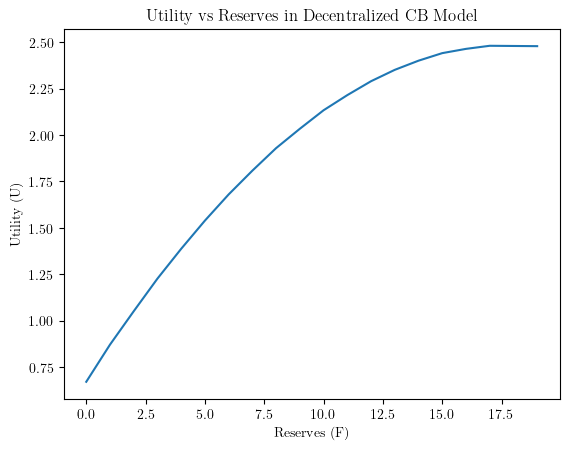

In [42]:
start = time.time()
fiscal = (3.0, .0, 0.0)
model = create_model(A=0.0, θgrid=10, Bgrid=10, Fgrid=20, Sgrid=10, B_h=1.5, F_h=2.0, τ=0.01, τg=0.01, τlt=0.01)
results = decentralizedcb_model(fiscal, model)
end = time.time()

# Check diagnostics
diagnostics = results[11]
if diagnostics['n_failed_convergence'] > 0:
    failed_indices = jnp.where(diagnostics['failed_convergence'])[0]
    print(f"⚠️  WARNING: {diagnostics['n_failed_convergence']} F values failed to converge!")
    print(f"   Failed F indices: {failed_indices}")
    print(f"   Max iterations reached: {diagnostics['max_iterations']}")
    print(f"   Max error: {diagnostics['max_error']:.2e}")
    
if diagnostics['n_negative_consumption'] > 0:
    negative_indices = jnp.where(diagnostics['has_negative'])[0]
    print(f"⚠️  WARNING: {diagnostics['n_negative_consumption']} F values have negative consumption!")
    print(f"   Negative consumption F indices: {negative_indices}")

print(jnp.argmax(results[1]))
print(results[10][jnp.argmax(results[1])])
print(results[8][jnp.argmax(results[1])])


# plot utility vs F grid
plt.plot(results[1])
plt.xlabel('Reserves (F)')
plt.ylabel('Utility (U)')
plt.title('Utility vs Reserves in Decentralized CB Model')

plt.show()

In [43]:
def centralized_model_fast(fiscal, model, max_iter=1_000, tol=1e-10):
    """
    Centralized (Ramsey) Liquidity Policy Model - FAST JAX VERSION.

    - Outer scan over DLA_grid (size Sgrid)
    - For each DLA, inner scan over f_grid in [0, DLA] (size Sgrid)
    - For each (DLA, f), solve Chat fixed point + Ramsey constraint
    using newton_solver and ramsey_constraint.
    """

    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    # Fiscal policy: (B, s1)
    B, s1 = fiscal

    # DLA grid (same support as NumPy version)
    DLA_grid = jnp.linspace(0.0, A + B, Sgrid)

    # ------------------------------------------------------
    # Inner solver: fixed DLA, scan over f_grid
    # ------------------------------------------------------
    def solve_for_DLA(carry_outer, DLA):
        """
        For a given DLA, solve over f_grid in [0, DLA].
        """

        # f-grid for this DLA
        f_grid = jnp.linspace(0.0, DLA, Sgrid)

        # State for each (DLA, f) in inner loop:
        # (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

        def solve_for_f(carry_inner, f):
            liquid = (DLA, f)

            Chat0       = jnp.array(1.0)
            error0      = jnp.inf
            it0         = 0
            zero_vec    = jnp.zeros((θgrid,))
            zero_scalar = 0.0

            state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)

            def cond_fun(state):
                Chat, error, it, *_ = state
                return jnp.logical_and(error > tol, it < max_iter)

            def body_fun(state):
                (Chat, _error, it, _R1, _Ls, _Ks, _Qs, _Xs, _Is, _Cs, _ECs, _ERs, _U) = state

                C0     = Chat
                v_init = jnp.ones((θgrid,))

                # Ramsey constraint
                def Kr(z):
                    return ramsey_constraint(z, C0, liquid, model)

                v_newton, _ = newton_solver(Kr, v_init)
                R1 = jnp.maximum(Rstar, v_newton)

                # Production block
                Ls = ((α * Z / R1) * (N / γ)**(α*γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
                Is = (1.0 - γ) * Ls
                Ks = κ * (N**γ) * (Is ** (1.0 - γ))
                Qs = Ls / Ks
                Xs = Qs ** (1.0 / γ)

                Cs = Z * Ks**α - Rstar * Is + Rstar * T - (Rstar**2) * C0 - (Rstar**2) * g0 - Rstar * g1 - g2 + (τlt - τg) * (Rstar**2) * B - τlt * (Rstar**2) * DLA + (1.0 + τlt) * (Rstar**2) * A

                ECs = jnp.sum(Cs * Π)
                ERs = jnp.sum(R1 * Π)

                Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)
                error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)
                U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs
                
                return (Chat_new, error, it + 1, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

            # Fixed-point loop in Chat
            (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

            # Outputs stacked over f-grid
            y = (Chat, U, ECs, ERs, R1, Ls, Ks, Qs, Xs, Is, Cs, f)
            
            return carry_inner, y

        # Inner scan over f_grid for this DLA
        _, inner_results = lax.scan(solve_for_f, None, f_grid)

        (C0star_row, Uhat_row, EC_row, ER_row, Spread_row, L_row, K_row, Q_row, X_row, I_row, C2_row, f_row) = inner_results

        y_outer = (C0star_row, Uhat_row, EC_row, ER_row, Spread_row, L_row, K_row, Q_row, X_row, I_row, C2_row, f_row)
        
        return carry_outer, y_outer

    # Outer scan over DLA_grid
    _, outer_results = lax.scan(solve_for_DLA, None, DLA_grid)

    (C0star, Uhat, EC, ER, Spread, L_arr, K_arr, Q_arr, X_arr, I_arr, C2_arr, f_grid_vec) = outer_results

    # Shape summary:
    # C0star, Uhat, EC, ER       -> (Sgrid, Sgrid)
    # Spread, L_arr, ... C2_arr  -> (Sgrid, Sgrid, θgrid)
    # f_grid_vec                 -> (Sgrid, Sgrid)
    # DLA_grid                   -> (Sgrid,)
    
    return (C0star, Uhat, Spread, L_arr, K_arr, Q_arr, X_arr, C2_arr, EC, ER, DLA_grid, f_grid_vec)



In [44]:
def decentralized_equilibrium(fiscal, reserves, model, max_iter=1_000, tol=1e-10):

    α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ = model

    # Unpack fiscal variables
    B, DLA, s1 = fiscal
    Fhat = reserves
    liquid = (DLA, s1)

    # -------------------------
    # Unconstrained values
    # -------------------------
    Lf = ((α * Z / Rstar) * (N / γ)**(α * γ)) ** (1.0 / (1.0 - α*(1.0-γ)))
    If = (1.0 - γ) * Lf
    Kf = κ * (N**γ) * (If ** (1.0 - γ))
    Qf = Lf / Kf
    Xf = Qf ** (1.0 / γ)
    Yf = Z * Kf**α  # not used, but kept for parity with your original code

    # -------------------------
    # Fixed‐point loop (Chat)
    # -------------------------
    Chat0   = jnp.array(1.0)
    error0  = jnp.inf
    it0     = 0

    zero_vec    = jnp.zeros((θgrid,))
    zero_scalar = 0.0

    # state = (Chat, error, it, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U)
    
    state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)

    # ---------------------------------------------
    # CONVERGENCE CRITERION
    # ---------------------------------------------
    def cond_fun(state):
        Chat, error, it, *_ = state
        return jnp.logical_and(error > tol, it < max_iter)

    # ---------------------------------------------
    # BODY OF FIXED-POINT ITERATION
    # ---------------------------------------------
    def body_fun(state):
        (Chat, _, it, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U) = state

        C0 = Chat

        # Newton solver on the constraint
        v_init = jnp.ones((θgrid,))

        def Fc(z):
            return financial_constraint(z, C0, liquid, Fhat, model)

        v_newton, _ = newton_solver(Fc, v_init)
        R1 = jnp.maximum(Rstar, v_newton)

        # Production
        Ls = ((α * Z / R1) * (N / γ)**(α*γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
        Is = (1.0 - γ) * Ls
        Ks = κ * (N**γ) * (Is ** (1.0 - γ))
        Qs = Ls / Ks
        Xs = Qs ** (1.0 / γ)

        # TB
        tb = -DLA + s1 + Rstar * g0 + g1

        # Consumption in t=1
        Cs = Z * Ks**α - Rstar * Is + Rstar * T - (Rstar**2) * C0 - (Rstar**2) * g0 - Rstar * g1 - g2 - τ * (Rstar**2) * Fhat + (τlt - τg) * (Rstar**2) * B - τlt * (Rstar**2) * DLA + (1.0 + τlt) * (Rstar**2) * A

        ECs = jnp.sum(Cs * Π)
        ERs = jnp.sum(R1 * Π)

        Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)
        error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)
        U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs
        return (Chat_new, error, it + 1, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U)

    # Run fixed‐point iteration
    (Chat, error, it, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

    # -------------------------
    # θ-threshold (unconstrained)
    # -------------------------
    tb = -DLA + s1 + Rstar * g0 + g1
    θhat = (T + Xf * N + Rstar * Fhat) / (Rstar * Chat + Lf + tb)

    # Bundle outputs like original function
    Fvalues = (Lf, If, Kf, Qf, Xf)
    grids   = (Chat, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U, θhat)

    return grids, Fvalues




In [45]:
def centequilibrium_fast(fiscal, reserves, model, max_iter=1_000, tol=1e-10):
    """
    JAX version of centequilibrium:
    - Uses ramsey_constraint (JAX version)
    - Uses newton_solver (JAX version)
    - Uses lax.while_loop for the outer fixed point in Chat
    """

    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z,
     θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A,
     F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid,
     Sgrid, B_l, B_h, κ) = model

    # Unpack fiscal and reserves
    B, DLA, s1 = fiscal
    f = reserves
    LA = DLA + f   # not directly used but kept for consistency
    liquid = (DLA, f)

    # -------------------------
    # Unconstrained values
    # -------------------------
    Lf = ((α * Z / Rstar) * (N / γ)**(α * γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
    If = (1.0 - γ) * Lf
    Kf = κ * (N**γ) * (If ** (1.0 - γ))
    Qf = Lf / Kf
    Xf = Qf ** (1.0 / γ)
    Yf = Z * Kf**α  # unused, but kept for parity

    # -------------------------
    # Fixed-point iteration in Chat
    # -------------------------
    Chat0   = jnp.array(1.0)
    error0  = jnp.inf
    it0     = 0

    zero_vec    = jnp.zeros((θgrid,))
    zero_scalar = 0.0

    # state = (Chat, error, it,
    #          R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U)
    state0 = (Chat0, error0, it0, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_vec, zero_scalar, zero_scalar, zero_scalar)


    # Convergence condition
    def cond_fun(state):
        Chat, error, it, *_ = state
        return jnp.logical_and(error > tol, it < max_iter)

    # Body of the loop
    def body_fun(state):
        (Chat, _, it, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U) = state

        C0 = Chat

        # Solve for R1(θ) with Ramsey constraint
        v_init = jnp.ones((θgrid,))

        def Fc(z):
            return ramsey_constraint(z, C0, liquid, model)

        v_newton, _ = newton_solver(Fc, v_init)
        R1 = jnp.maximum(Rstar, v_newton)
        R1 = jnp.minimum(Rstar/(1 - θ_h), R1)  # Cap interest rates to avoid numerical issues
        # Production side
        Ls = ((α * Z / R1) * (N / γ)**(α * γ)) ** (1.0 / (1.0 - α*(1.0 - γ)))
        Is = (1.0 - γ) * Ls
        Ks = κ * (N**γ) * (Is ** (1.0 - γ))
        Qs = Ls / Ks
        Xs = Qs ** (1.0 / γ)

        # Consumption at t=1 (Ramsey / centralized policy)
        Cs = Z * Ks**α - Rstar * Is + Rstar * T - (Rstar**2) * C0 - (Rstar**2) * g0 - Rstar * g1 - g2 + (τlt - τg) * (Rstar**2) * B - τlt * (Rstar**2) * DLA + (1.0 + τlt) * (Rstar**2) * A
        Cs = Cs / (Rstar * (1.0 - θgrid * Π))

        ECs = jnp.sum(Cs * Π)
        ERs = jnp.sum(R1 * Π)

        Chat_new = (β * Rstar * ERs) ** (-1.0 / σ)
        error = jnp.where(jnp.any(Cs < 0.0), jnp.inf, (Chat_new - Chat) ** 2)
        U = Chat_new**(1.0 - σ) / (1.0 - σ) + β * ECs

        return (Chat_new, error, it + 1, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U)

    # Run the fixed-point loop
    (Chat, error, it, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U) = lax.while_loop(cond_fun, body_fun, state0)

    # -------------------------
    # θ-threshold (unconstrained)
    # -------------------------
    tb   = Rstar * g0 + g1 - Rstar * DLA + s1 + f
    θhat = (T + Xf * N + f) / (Rstar * Chat + Lf + tb)

    Fvalues = (Lf, If, Kf, Qf, Xf)
    grids   = (Chat, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U, θhat)

    return grids, Fvalues



In [46]:
# ---------------------------------------------
# Government Best Response (given F) – JAX
# ---------------------------------------------

def gov_best_response(model, s1=0.0):
    """
    For each F in model.F_grid, find the (B, DLA) that maximizes U
    using decentralizedgov_model (which already scans over DLA).

    Returns:
        UhatRR    : (Fgrid,)            max U for each F
        Chatstar  : (Fgrid,)            optimal C0
        Bstar     : (Fgrid,)            optimal B for each F
        DLAstar   : (Fgrid,)            optimal DLA for each F
        tbstar    : (Fgrid,)            TB at t=1 for each F

        Spreadstar: (Fgrid, θgrid)
        Lsstar    : (Fgrid, θgrid)
        Ksstar    : (Fgrid, θgrid)
        Qsstar    : (Fgrid, θgrid)
        Xsstar    : (Fgrid, θgrid)
        C2sstar   : (Fgrid, θgrid)
        ECstar    : (Fgrid,)
        ERstar    : (Fgrid,)
        Ysstar    : (Fgrid, θgrid)
        Fvals     : (Fgrid,)  = model.F_grid
        diagnostics: dict with convergence and negative consumption info
    """
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model


    # B grid: size Bgrid with boundaries B_l and B_h
    B_grid = jnp.linspace(B_l, B_h, Bgrid)

    def br_to_F(Fhat):
        """
        Best response (over B and DLA) for a fixed Fhat.
        """

        def br_to_B(B):
            fiscal = (B, s1)
            (C0star, Uhat, Spread,
             L_arr, K_arr, Q_arr, X_arr,
             C2_arr, EC, ER, DLA_grid, diagnostics) = decentralizedgov_model(fiscal, Fhat, model)

            # Uhat: shape (Sgrid,) over DLA
            idx = jnp.argmax(Uhat)   # optimal DLA index for this B, Fhat

            U_star     = Uhat[idx]
            DLA_star   = DLA_grid[idx]
            Chat_star  = C0star[idx]
            Spread_star = Spread[idx, :]
            L_star     = L_arr[idx, :]
            K_star     = K_arr[idx, :]
            Q_star     = Q_arr[idx, :]
            X_star     = X_arr[idx, :]
            C2_star    = C2_arr[idx, :]
            EC_star    = EC[idx]
            ER_star    = ER[idx]
            Ys_star    = Z * K_star**α
            
            # Extract diagnostics for this B
            diag_info = (diagnostics['n_failed_convergence'], 
                        diagnostics['n_negative_consumption'],
                        diagnostics['max_iterations'],
                        diagnostics['max_error'])

            return (U_star, DLA_star, Chat_star, Spread_star, L_star, K_star, Q_star, X_star, C2_star, EC_star, ER_star, Ys_star, B, diag_info)

        # vmap over B_grid
        (U_B, DLA_B, Chat_B, Spread_B, L_B, K_B, Q_B, X_B, C2_B, EC_B, ER_B, Ys_B, B_vals, diag_B) = jax.vmap(br_to_B)(B_grid)


        # Best B for this Fhat
        idx_B = jnp.argmax(U_B)

        U_F        = U_B[idx_B]
        DLA_star_F = DLA_B[idx_B]
        B_star_F   = B_vals[idx_B]
        Chat_star_F = Chat_B[idx_B]
        Spread_star_F = Spread_B[idx_B, :]
        L_star_F   = L_B[idx_B, :]
        K_star_F   = K_B[idx_B, :]
        Q_star_F   = Q_B[idx_B, :]
        X_star_F   = X_B[idx_B, :]
        C2_star_F  = C2_B[idx_B, :]
        EC_star_F  = EC_B[idx_B]
        ER_star_F  = ER_B[idx_B]
        Ys_star_F  = Ys_B[idx_B, :]
        tb_star_F  = -Rstar * DLA_star_F + s1 + Rstar * g0 + g1
        
        # Aggregate diagnostics across all B values for this F
        # diag_B is shape (Bgrid, 4) where 4 = (n_failed, n_negative, max_iter, max_error)
        n_failed_F = jnp.sum(diag_B[0])  # Total failed across all B
        n_negative_F = jnp.sum(diag_B[1])  # Total negative across all B
        max_iter_F = jnp.max(diag_B[2])  # Max iterations across all B
        max_error_F = jnp.max(diag_B[3])  # Max error across all B
        
        diag_F = (n_failed_F, n_negative_F, max_iter_F, max_error_F)

        return (U_F, Chat_star_F, B_star_F, DLA_star_F, tb_star_F, Spread_star_F, L_star_F, K_star_F, Q_star_F, X_star_F, C2_star_F, EC_star_F, ER_star_F, Ys_star_F, Fhat, diag_F)

    # vmap over F_grid
    (UhatRR, Chatstar, Bstar, DLAstar, tbstar, Spreadstar, Lsstar, Ksstar, Qsstar, Xsstar, C2sstar, ECstar, ERstar, Ysstar, Fvals, diag_all) = jax.vmap(br_to_F)(F_grid)
    
    # Aggregate diagnostics across all F values
    # diag_all is shape (Fgrid, 4)
    total_failed = jnp.sum(diag_all[0])
    total_negative = jnp.sum(diag_all[1])
    max_iterations = jnp.max(diag_all[2])
    max_error = jnp.max(diag_all[3])
    
    diagnostics = {
        'total_failed_convergence': total_failed,
        'total_negative_consumption': total_negative,
        'max_iterations': max_iterations,
        'max_error': max_error,
        'any_issues': jnp.logical_or(total_failed > 0, total_negative > 0)
    }

    return (UhatRR, Chatstar, Bstar, DLAstar, tbstar, Spreadstar, Lsstar, Ksstar, Qsstar, Xsstar, C2sstar, ECstar, ERstar, Ysstar, Fvals, diagnostics)

✓ All solutions converged successfully with positive consumption
Gov best response computed in 2.61 seconds


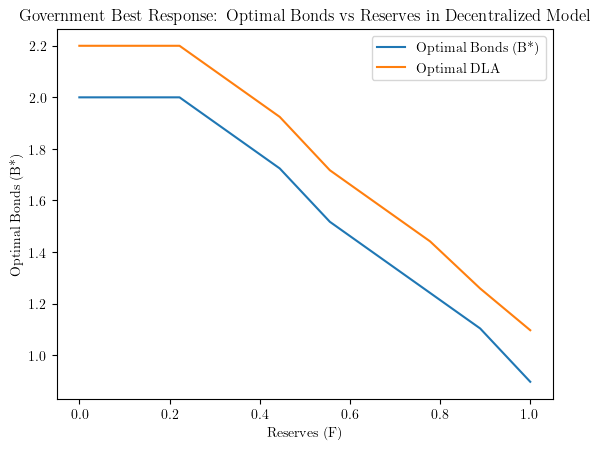

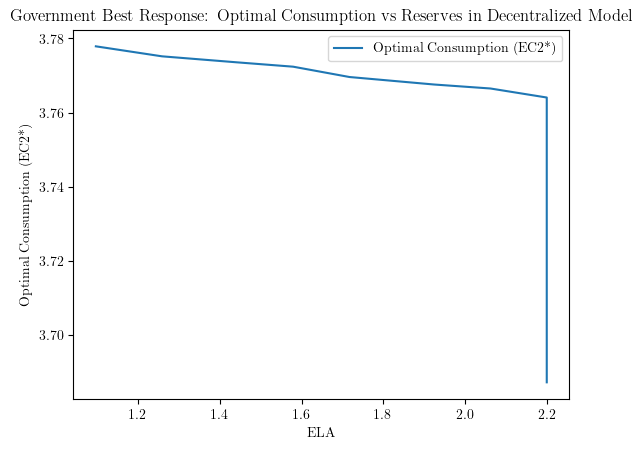

[0.         0.         0.         0.         0.         0.
 0.         0.         0.04494649 0.        ]
(10,)


In [47]:
# add a test of best response for gov_best_response
start = time.time()
model = create_model(A=0.2, θgrid=20, Bgrid=30, Fgrid=10, Sgrid=30, B_h=2.0, F_h=1.0, τ=0.04, τg=0.04, τlt=0.02)
results = gov_best_response(model, s1=0.0)
end = time.time()

# Check diagnostics
diagnostics = results[15]
if diagnostics['any_issues']:
    print(f"⚠️  WARNING: Issues found in gov_best_response!")
    if diagnostics['total_failed_convergence'] > 0:
        print(f"   Total failed convergences: {diagnostics['total_failed_convergence']}")
    if diagnostics['total_negative_consumption'] > 0:
        print(f"   Total negative consumptions: {diagnostics['total_negative_consumption']}")
    print(f"   Max iterations: {diagnostics['max_iterations']}")
    print(f"   Max error: {diagnostics['max_error']:.2e}")
else:
    print("✓ All solutions converged successfully with positive consumption")
    
print("Gov best response computed in {:.2f} seconds".format(end - start))

# plot the best response Bstar vs Fvals and DLAstar vs Fvals
plt.plot(results[14], results[2], label='Optimal Bonds (B*)')
plt.plot(results[14], results[3], label='Optimal DLA')
plt.xlabel('Reserves (F)')
plt.ylabel('Optimal Bonds (B*)')
plt.title('Government Best Response: Optimal Bonds vs Reserves in Decentralized Model')
plt.legend()
plt.show()

# plot consumption vs Fvals
plt.plot(results[3], results[11], label='Optimal Consumption (EC2*)')
plt.xlabel('ELA ')
plt.ylabel('Optimal Consumption (EC2*)')
plt.title('Government Best Response: Optimal Consumption vs Reserves in Decentralized Model')
plt.legend()
plt.show()

print(model.A + results[2] - results[3])
print(results[0].shape)
  

In [48]:
# ---------------------------------------------------
# Central Bank Best Response – JAX
# ---------------------------------------------------

def cb_best_response(model, s1=0.0):
    """
    For each DLAhat in a DLA grid, the CB chooses F to maximize U
    using decentralizedcb_model (which already scans over F_grid).

    Returns arrays indexed by DLAhat (size Sgrid):
        UstarCB     : (Sgrid,)
        ChatstarCB  : (Sgrid,)
        FstarCB     : (Sgrid,)
        DLACB       : (Sgrid,)
        tbCB        : (Sgrid,)

        SpreadstarCB: (Sgrid, θgrid)
        LsstarCB    : (Sgrid, θgrid)
        KsstarCB    : (Sgrid, θgrid)
        QsstarCB    : (Sgrid, θgrid)
        XsstarCB    : (Sgrid, θgrid)
        C2sstarCB   : (Sgrid, θgrid)
        ECstarCB    : (Sgrid,)
        ERstarCB    : (Sgrid,)
        YsstarCB    : (Sgrid, θgrid)
        DLA_grid    : (Sgrid,)
        diagnostics : dict with convergence and negative consumption info
    """
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    # Grid of DLA choices (as in your original CB BR block)
    DLA_grid = jnp.linspace(0.0, A + B_h, Sgrid)

    

    def br_for_DLA(DLAhat):
        
        fiscal = (jnp.maximum(0, DLAhat-A), DLAhat, s1)

        (C0star, Uhat, Spread, L_arr, K_arr, Q_arr, X_arr, C2_arr, EC, ER, Fvals, diagnostics) = decentralizedcb_model(fiscal, model)

        # Uhat: (Fgrid,)
        idx = jnp.argmax(Uhat)

        U_CB       = Uhat[idx]
        F_star     = Fvals[idx]
        Spread_star = Spread[idx, :]
        Ls_star    = L_arr[idx, :]
        Ks_star    = K_arr[idx, :]
        Qs_star    = Q_arr[idx, :]
        Xs_star    = X_arr[idx, :]
        C2_star    = C2_arr[idx, :]
        EC_star    = EC[idx]
        ER_star    = ER[idx]
        Chat_star  = C0star[idx]
        Ys_star    = Z * Ks_star**α

        tb = -Rstar * DLAhat + s1 + Rstar * g0 + g1
        
        # Extract diagnostic info to aggregate
        diag_info = (diagnostics['n_failed_convergence'], 
                    diagnostics['n_negative_consumption'],
                    diagnostics['max_iterations'],
                    diagnostics['max_error'])
        
        return (U_CB, Chat_star, F_star, DLAhat, tb, Spread_star, Ls_star, Ks_star, Qs_star, Xs_star, C2_star, EC_star, ER_star, Ys_star, diag_info)

    (UstarCB, ChatstarCB, FstarCB, DLACB, tbCB, SpreadstarCB, LsstarCB, KsstarCB, QsstarCB, XsstarCB, C2sstarCB, ECstarCB, ERstarCB, YsstarCB, diag_DLA) = jax.vmap(br_for_DLA)(DLA_grid)
    
    # Aggregate diagnostics across all DLA values
    # diag_DLA is tuple of 4 arrays: (n_failed, n_negative, max_iter, max_error) each of shape (Sgrid,)
    total_failed = jnp.sum(diag_DLA[0])
    total_negative = jnp.sum(diag_DLA[1])
    max_iterations = jnp.max(diag_DLA[2])
    max_error = jnp.max(diag_DLA[3])
    
    diagnostics = {
        'total_failed_convergence': total_failed,
        'total_negative_consumption': total_negative,
        'max_iterations': max_iterations,
        'max_error': max_error,
        'any_issues': jnp.logical_or(total_failed > 0, total_negative > 0)
    }

    return (UstarCB, ChatstarCB, FstarCB, DLACB, tbCB, SpreadstarCB, LsstarCB, KsstarCB, QsstarCB, XsstarCB, C2sstarCB, ECstarCB, ERstarCB, YsstarCB, DLA_grid, diagnostics) 

In [49]:
# ---------------------------------------------------
# Social Planner Best Response – JAX
# ---------------------------------------------------

def centralized_best_response_fast(model, s1=0.0):
    """
    For each B in a debt grid, the planner chooses (DLA, f)
    to maximize U using centralized_model_fast.

    Returns:
        UB   : (Bgrid,)  max U for each B
        DLAB : (Bgrid,)  optimal DLA(B)
        FB   : (Bgrid,)  optimal f(B)
        TB   : (Bgrid,)  transfers to HHs = DLAB - FB
        SB   : (Bgrid,)  SWF savings = A + B - DLAB
        Bvals: (Bgrid,)  B grid
    """
    (α, σ, γ, τ, τg, τlt, β, ρ, Rstar, s, N, T, Z, θ_l, θ_h, Fgrid, θgrid, g0, g1, g2, A, F_l, F_h, θ_grid, F_grid, Π, Rbar, Bgrid, Sgrid, B_l, B_h, κ) = model

    # Debt grid for the centralized problem:
    #   boundaries B_l and B_h + F_h  (as in your original code)
    B_grid = jnp.linspace(B_l, B_h + F_h, Bgrid)

    def br_for_B(B):
        fiscal = (B, s1)

        (C0star, Uhat, Spread,
         L_arr, K_arr, Q_arr, X_arr,
         C2_arr, EC, ER, DLA_grid, f_grid_vec) = centralized_model_fast(fiscal, model)

        # Uhat: (Sgrid, Sgrid) over (DLA_index, f_index)
        U_flat = jnp.reshape(Uhat, (-1,))
        idx_flat = jnp.argmax(U_flat)

        # Recover 2D indices (i_DLA, i_f)
        i_DLA = idx_flat // Sgrid
        i_f   = idx_flat %  Sgrid

        U_B   = Uhat[i_DLA, i_f]
        DLA_star = DLA_grid[i_DLA]
        F_star   = f_grid_vec[i_DLA, i_f]

        TB = DLA_star - F_star
        S_swf = A + B - DLA_star

        return (U_B, DLA_star, F_star, TB, S_swf, B)

    (UB, DLAB, FB, TB, SB, Bvals) = jax.vmap(br_for_B)(B_grid)

    return UB, DLAB, FB, TB, SB, Bvals


In [50]:
def run_experiments(model, s1=0.0):
    """
    Run the full experiment for a given model:
      - Government best response to reserves F
      - Central Bank best response to DLA
      - Centralized (Ramsey) benchmark

    Produces a 1x3 matplotlib figure with:
      1) CB best response in (DLA, F) space
      2) Government best responses in (F, B, DLA, long-term)
      3) Equilibria comparison: Gov BR vs CB BR vs General Gov (centralized)
    """

    # -----------------------------------------
    # 1. Government best response (given F)
    # -----------------------------------------
    # gov_best_response returns 16 elements: (UhatRR, Chatstar, Bstar, DLAstar, tbstar,
    #                                         Spreadstar, Lsstar, Ksstar, Qsstar, Xsstar,
    #                                         C2sstar, ECstar, ERstar, Ysstar, Fvals, diagnostics_gov)
    (UhatRR, Chatstar, Bstar, DLAstar, tbstar,
     Spreadstar, Lsstar, Ksstar, Qsstar, Xsstar,
     C2sstar, ECstar, ERstar, Ysstar, Fvals, diagnostics_gov) = gov_best_response(model, s1)

    # -----------------------------------------
    # 2. Central Bank best response (given DLA)
    # -----------------------------------------
    # cb_best_response returns 16 elements: (UstarCB, ChatstarCB, FstarCB, DLACB, tbCB,
    #                                        SpreadstarCB, LsstarCB, KsstarCB, QsstarCB, XsstarCB,
    #                                        C2sstarCB, ECstarCB, ERstarCB, YsstarCB, DLA_grid, diagnostics_cb)
    (UstarCB, ChatstarCB, FstarCB, DLACB, tbCB,
     SpreadstarCB, LsstarCB, KsstarCB, QsstarCB, XsstarCB,
     C2sstarCB, ECstarCB, ERstarCB, YsstarCB, DLA_grid_cb, diagnostics_cb) = cb_best_response(model, s1)

    # -----------------------------------------
    # 3. Centralized problem (General Government)
    # -----------------------------------------
    UB, DLAB, FB, TB, SB, Bvals = centralized_best_response_fast(model, s1)

    # Find planner's optimum point for (Fgraph, Tgraph)
    UB_np = np.asarray(UB)
    max_idx = np.unravel_index(np.argmax(UB_np), UB_np.shape)

    FB_np = np.asarray(FB)
    TB_np = np.asarray(TB)
    B_np = np.asarray(Bvals)
    

    Fgraph = FB_np[max_idx]   # Reserves at planner optimum
    Tgraph = TB_np[max_idx]   # Transfers at planner optimum (used as y in equilibrium plot)
    Bgraph = B_np[max_idx]    # Government debt at planner optimum

    # -----------------------------------------
    # 4. Convert relevant arrays to NumPy
    # -----------------------------------------
    DLACB_np   = np.asarray(DLACB)       # (Sgrid,) CB BR DLA
    FstarCB_np = np.asarray(FstarCB)     # (Sgrid,) CB BR F

    DLAstar_np = np.asarray(DLAstar)     # (Fgrid,) Gov BR DLA(F)
    Bstar_np   = np.asarray(Bstar)       # (Fgrid,) Gov BR B(F)

    F_grid_np  = np.asarray(model.F_grid)
    A_val      = float(model.A)

    # -----------------------------------------
    # 5. Make the figure
    # -----------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(16, 8))

    # ---------------------------------------------------
    # Panel 1: Best Response of the Central Bank (CB BR)
    # ---------------------------------------------------
    axs[0].scatter(DLACB_np, FstarCB_np,
                   color='red', label='CB Best Response')

    axs[0].set_title('Best Response of the Central Bank')
    axs[0].set_xlabel('Disposable Liquid Assets')
    axs[0].set_ylabel('Reserves')

    axs[0].legend(loc='upper right', fontsize=8)

    # ---------------------------------------------------
    # Panel 2: Best Responses of the Government
    # ---------------------------------------------------
    # Horizontal line at A
    axs[1].axhline(A_val, color='gray', linestyle='--')

    # Government BR in terms of DLA, B, and long-term assets
    axs[1].scatter(F_grid_np, DLAstar_np, label='DLA')
    axs[1].scatter(F_grid_np, Bstar_np, marker='+', label='Gov Debt')

    # Long-Term (A + B - DLA)
    long_term_np = A_val + Bstar_np - DLAstar_np
    axs[1].scatter(F_grid_np, long_term_np, label='Long-Term')

    axs[1].set_title('Best Responses of the Government')
    axs[1].set_xlabel('Reserves')
    axs[1].set_ylabel('')

    axs[1].legend(
        loc='upper center',
        ncol=3,
        fontsize=10
    )

    # ---------------------------------------------------
    # Panel 3: Equilibria
    # ---------------------------------------------------
    axs[2].axhline(A_val, color='gray', linestyle='--')

    # CB Best Response curve in (F, DLA)
    axs[2].plot(FstarCB_np, DLACB_np,
                   color='red', label='CB Best Response')

    # Gov Best Response curve in (F, DLA)
    axs[2].plot(F_grid_np, DLAstar_np,
                   color='blue', label='Gov Best Response')

    # General Government (centralized planner) point (Fgraph, Tgraph)
    axs[2].scatter(Fgraph, Tgraph,
                   color='green', marker='D', label='General Gov')

    axs[2].set_title('Equilibria')
    axs[2].set_xlabel('Reserves')
    axs[2].set_ylabel('Disposable Liquid Assets')

    axs[2].legend(
        loc='upper right',
        ncol=1,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    # Optionally return all computed objects if you want to reuse them
    return {
        "UhatRR": UhatRR,
        "Chatstar": Chatstar,
        "Bstar": Bstar,
        "DLAstar": DLAstar,
        "tbstar": tbstar,
        "Spreadstar": Spreadstar,
        "Lsstar": Lsstar,
        "Ksstar": Ksstar,
        "Qsstar": Qsstar,
        "Xsstar": Xsstar,
        "C2sstar": C2sstar,
        "ECstar": ECstar,
        "ERstar": ERstar,
        "Ysstar": Ysstar,
        "Fvals": Fvals,
        "diagnostics_gov": diagnostics_gov,
        "UstarCB": UstarCB,
        "ChatstarCB": ChatstarCB,
        "FstarCB": FstarCB,
        "DLACB": DLACB,
        "tbCB": tbCB,
        "SpreadstarCB": SpreadstarCB,
        "LsstarCB": LsstarCB,
        "KsstarCB": KsstarCB,
        "QsstarCB": QsstarCB,
        "XsstarCB": XsstarCB,
        "C2sstarCB": C2sstarCB,
        "ECstarCB": ECstarCB,
        "ERstarCB": ERstarCB,
        "YsstarCB": YsstarCB,
        "DLA_grid_cb": DLA_grid_cb,
        "diagnostics_cb": diagnostics_cb,
        "UB": UB,
        "DLAB": DLAB,
        "FB": FB,
        "TB": TB,
        "SB": SB,
        "Bvals": Bvals,
        "Fgraph": Fgraph,
        "Tgraph": Tgraph,
        "Bgraph": Bgraph,
        "fig": fig,
        "axs": axs
    }



In [51]:
def plot_extensive_and_intensive_margins(model, s1=0.0, max_iter=1_000, tol=1e-10):
    """
    For given model and s1, compute (θ̂, R_s(θ)) for:
      - Decentralized equilibrium  (decentralized_equilibrium)
      - Centralized equilibrium    (centequilibrium_fast)
    as functions of (DLA, F).

    Panel 1 (Extensive Margin): plot the probability P(θ > θ̂) instead of θ̂ itself,
                                as a function of F (for fixed DLA) and of DLA (for fixed F).

    Panel 2 (Intensive Margin): plot R_s(θ) for selected (DLA, F) combinations.

    Reference lines are evaluated at grid points closest to:
      DLA* = 1.11,  F* = 1.11
    """

    # Grids
    DLA_grid = jnp.linspace(0.0, model.A + model.B_h, model.Sgrid)
    F_grid   = model.F_grid  # jnp array length Fgrid

    Sg = model.Sgrid
    Fg = model.Fgrid
    Tg = model.θgrid

    # Containers (NumPy for plotting)
    thetahat     = np.zeros((Sg, Fg))
    Rs           = np.zeros((Sg, Fg, Tg))
    thetahat_cet = np.zeros((Sg, Fg))
    Rscet        = np.zeros((Sg, Fg, Tg))

    # ------------------------------------------------
    # 1. Fill θ̂(DLA,F) and R_s(DLA,F,θ)
    # ------------------------------------------------
    for j in range(Sg):
        DLA_val = float(DLA_grid[j])
        fiscal_dec = (0.0, DLA_val, s1)   # (B=0, DLA, s1)

        for k in range(Fg):
            F_val = float(F_grid[k])

            # ----- Decentralized -----
            grids_dec, _ = decentralized_equilibrium(
                fiscal_dec, F_val, model, max_iter=max_iter, tol=tol
            )
            # grids_dec = (Chat, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U, θhat)
            θ_dec = float(grids_dec[11])
            R_dec = np.asarray(grids_dec[1])   # shape (θgrid,)

            thetahat[j, k] = min(θ_dec, float(model.θ_h))
            Rs[j, k, :]    = R_dec

            # ----- Centralized (if you want to use it later) -----
            grids_cen, _ = centequilibrium_fast(
                fiscal_dec, F_val, model, max_iter=max_iter, tol=tol
            )
            θ_cen = float(grids_cen[11])
            R_cen = np.asarray(grids_cen[1])

            thetahat_cet[j, k] = min(θ_cen, float(model.θ_h))
            Rscet[j, k, :]     = R_cen

    # ------------------------------------------------
    # 2. Convert to NumPy & compute probabilities P(θ > θ̂)
    # ------------------------------------------------
    DLA_grid_np = np.asarray(DLA_grid)
    F_grid_np   = np.asarray(F_grid)
    θ_grid_np   = np.asarray(model.θ_grid)
    Π_np        = np.asarray(model.Π)

    # P_dec[j,k] = sum_{θ_i > θ̂(j,k)} Π_i
    prob_dec = np.zeros_like(thetahat)
    for j in range(Sg):
        for k in range(Fg):
            θ_thr = thetahat[j, k]
            mask  = θ_grid_np > θ_thr    # strictly higher
            prob_dec[j, k] = float((Π_np[mask]).sum())

    # Optionally, you could also compute prob_cet from thetahat_cet if needed.

    # ------------------------------------------------
    # 3. Choose indices closest to DLA = 1.11 and F = 1.11
    # ------------------------------------------------
    DLA_target = 1.0
    F_target   = 1.0

    idx_dla_111 = int(np.argmin(np.abs(DLA_grid_np - DLA_target)))
    idx_f_111   = int(np.argmin(np.abs(F_grid_np - F_target)))

    DLA_at_idx = DLA_grid_np[idx_dla_111]
    F_at_idx   = F_grid_np[idx_f_111]

    # ------------------------------------------------
    # 4. Build plots
    # ------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # -------------------------------
    # Panel 1: Extensive Margin
    # Plot probability mass above threshold: P(θ > θ̂)
    # -------------------------------
    axs[0].axhline(0.0, color='gray', linestyle='--')

    # P(θ > θ̂) as a function of F for fixed DLA
    axs[0].plot(F_grid_np,
               prob_dec[0, :],
               color='blue',
               label='F(DLA=0)')
    axs[0].plot(F_grid_np,
               prob_dec[idx_dla_111, :],
               color='red',
               label=f'F(DLA≈{DLA_at_idx:.2f})')

    # P(θ > θ̂) as a function of DLA for fixed F
    axs[0].plot(DLA_grid_np,
                prob_dec[:, 0],
                color='blue',
                linestyle='--',
                label='DLA(F=0)')
    axs[0].plot(DLA_grid_np,
                prob_dec[:, idx_f_111],
                color='red',
                linestyle='--',
                label=f'DLA(F≈{F_at_idx:.2f})')

    axs[0].set_title('Extensive Margin')
    axs[0].set_xlabel('Reserves / DLA')
    axs[0].set_ylabel(r'$\Pr(\theta > \hat{\theta})$')

    axs[0].legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=10
    )

    # -------------------------------
    # Panel 2: Intensive Margin (unchanged)
    # -------------------------------
    axs[1].axhline(1.0, color='gray', linestyle='--')

    axs[1].plot(θ_grid_np,
                Rs[0, 0, :],
                color='blue',
                label='DLA=0, F=0')
    axs[1].plot(θ_grid_np,
                Rs[0, idx_f_111, :],
                color='red',
                label=f'DLA=0, F≈{F_at_idx:.2f}')

    axs[1].plot(θ_grid_np,
                Rs[idx_dla_111, 0, :],
                color='blue',
                linestyle='--',
                label=f'DLA≈{DLA_at_idx:.2f}, F=0')
    axs[1].plot(θ_grid_np,
                Rs[idx_dla_111, idx_f_111, :],
                color='red',
                linestyle='--',
                label=f'DLA≈{DLA_at_idx:.2f}, F≈{F_at_idx:.2f}')

    axs[1].set_title('Intensive Margin')
    axs[1].set_xlabel(r'$\theta$')
    axs[1].set_ylabel(r'$R_s$')

    axs[1].legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

    return {
        "DLA_grid": DLA_grid_np,
        "F_grid": F_grid_np,
        "DLA_idx_1_11": idx_dla_111,
        "F_idx_1_11": idx_f_111,
        "thetahat": thetahat,
        "prob_dec": prob_dec,
        "Rs": Rs,
        "thetahat_cet": thetahat_cet,
        "Rscet": Rscet,
        "fig": fig,
        "axs": axs
    }

In [52]:
separator = "-" * 50

# Load parameters

model = create_model(A=.5, θgrid=3, Bgrid=10, Fgrid=10, Sgrid=10, B_h=2.0, F_h=2.0, τ=0.04, τg=0.04, τlt=0.03)

# Frictionless Model

frictionless = frictionless_model(model)
# C0star, L, I, K, Q, X, C, Ufb
print(separator)
print("BENCHMARK MODEL")
print(separator)
print("Benchmark Model: C0star = ", frictionless[0])
print("Benchmark Model: Consumption at t=2 ", frictionless[6])
print("Benchmark Model: Optimal Lending = ", frictionless[1])
print("Benchmark Model: Optimal Demand for Tradable Inputs = ", frictionless[2])
print("Benchmark Model: Optimal Capital = ", frictionless[3])
print("Benchmark Model: Price of Capital = ", frictionless[4])
print("Benchmark Model: Optimal Exchange Rate = ", frictionless[5])
print("Benchmark Model: Expected Discounted Utility = ", frictionless[7]) 
print("Benchmark Model: Marginal Product of Capital = ", frictionless[8])
print("Benchmark Model: Output = ", frictionless[9])
print("Marginal Utility at t = 0: ", (frictionless[0])**(-model.σ))

print(separator)

Ufb = frictionless[7]
Xfb = frictionless[5]
Qfb = frictionless[4]
Kfb = frictionless[3]

vectorslf = laissez_faire(Ufb, model)    
# (Chat, error, it, R1, Ls, Ks, Qs, Xs, Is, Cs, ECs, ERs, U)

print("Laissez-Faire Model: C0star = ", vectorslf[0])
print("Laissez-Faire Model: Consumption at t=2 ", vectorslf[10])
print("Laissez-Faire Model: Expected Interest Rate = ", vectorslf[11])
print("Laissez-Faire Model: Expected Discounted Utility = ", vectorslf[12])
print("Laissez-Faire Model:Marginal Utility at t = 0: ", (vectorslf[0])**(-model.σ))
print("Laissez-Faire Model:: θhat = ", (model.T + frictionless[5]*model.N)/(model.Rstar*vectorslf[0] + frictionless[3]*frictionless[4]))
print("Laissez-Faire Model:: Probability of crisis = ", jnp.sum(model.Π[model.θ_grid > ((model.T + frictionless[5]*model.N)/(model.Rstar*vectorslf[0] + frictionless[3]*frictionless[4]))]))



g_grid = jnp.linspace(0.0, 0.5, 10)

# This assumes:
# - laissez_faire(Ufb, model) returns something where vec[0] is the scalar C*
# - Xfb, Qfb, Kfb, Ufb are scalar (or 0-d) jnp arrays / Python floats

def compute_for_g(g0):
    # Build model for this g0 (same g0 for g0, g1, g2 as in your loop)
    model = create_model(θgrid=10, Bgrid=10, Fgrid=10, Sgrid=10, g0=g0, g1=g0, g2=g0)

    # Get laissez-faire outcome
    vec = laissez_faire(Ufb, model)
    C = vec[0]  # scalar C*

    # θ* formula (same as in your loop)
    theta = (model.T + Xfb * model.N) / (
        model.Rstar * C
        + Qfb * Kfb
        + model.Rbar * model.g0
        + model.g1
    )

    return C, theta

# Vectorize over g_grid
#Cstar, θstar = vmap(compute_for_g)(g_grid)

#print(θstar)

--------------------------------------------------
BENCHMARK MODEL
--------------------------------------------------
Benchmark Model: C0star =  1.0259783520851542
Benchmark Model: Consumption at t=2  1.7798625598459559
Benchmark Model: Optimal Lending =  3.474454549241481
Benchmark Model: Optimal Demand for Tradable Inputs =  1.7372272746207404
Benchmark Model: Optimal Capital =  2.636078355907305
Benchmark Model: Price of Capital =  1.3180391779536529
Benchmark Model: Optimal Exchange Rate =  1.7372272746207411
Benchmark Model: Expected Discounted Utility =  0.7161899973727616
Benchmark Model: Marginal Product of Capital =  1.3180391779536527
Benchmark Model: Output =  4.34306818655185
Marginal Utility at t = 0:  0.9499999999999998
--------------------------------------------------
Laissez-Faire Model: C0star =  0.7900491842187805
Laissez-Faire Model: Consumption at t=2  0.5453066034680025
Laissez-Faire Model: Expected Interest Rate =  1.6864292912199095
Laissez-Faire Model: Expected

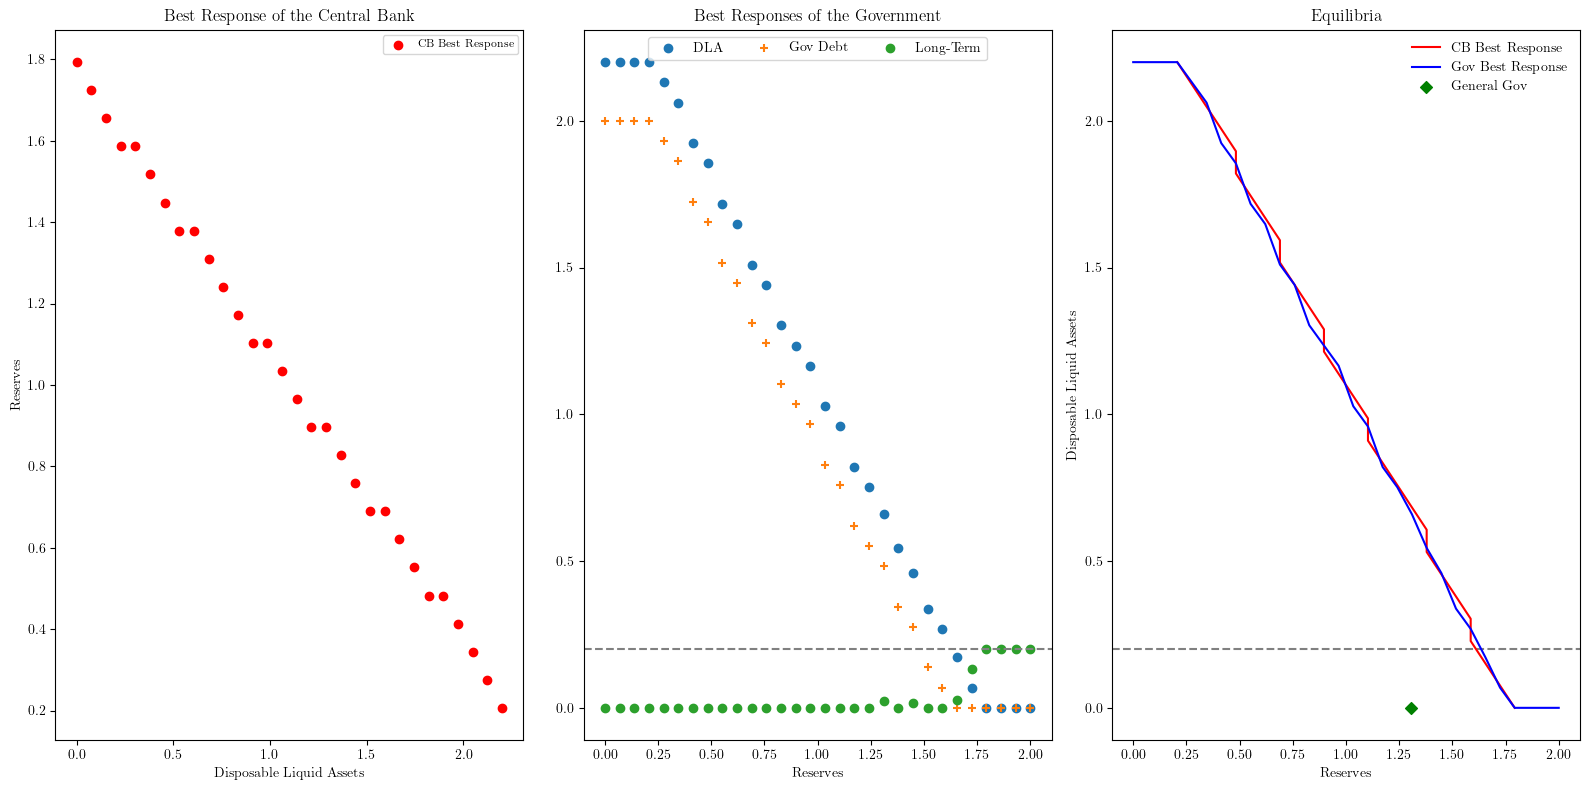

✓ All GOV solutions converged successfully with positive consumption
✓ All solutions converged successfully with positive consumption
Elapsed: 26.742674 seconds


In [53]:
# Example baseline model
#model = create_model(A=.5, θgrid=10, Bgrid=10, Fgrid=20, Sgrid=20, B_h=2.0)
#model = create_model(τ=0.04, τlt=.02) 
import time
start = time.time()
model = create_model(A=0.2, θgrid=30, Bgrid=30, Fgrid=30, Sgrid=30, B_h=2.0, F_h=2.0, τ=0.04, τg=0.04, τlt=0.02)
results = run_experiments(model,  s1=0.0)
# Check diagnostics
diagnostics = results["diagnostics_gov"]
if diagnostics['any_issues']:
    print(f"⚠️  WARNING: Issues found in gov_best_response!")
    if diagnostics['total_failed_convergence'] > 0:
        print(f"   Total failed convergences: {diagnostics['total_failed_convergence']}")
    if diagnostics['total_negative_consumption'] > 0:
        print(f"   Total negative consumptions: {diagnostics['total_negative_consumption']}")
    print(f"   Max iterations: {diagnostics['max_iterations']}")
    print(f"   Max error: {diagnostics['max_error']:.2e}")
else:
    print("✓ All GOV solutions converged successfully with positive consumption")

diagnostics = results["diagnostics_cb"]
if diagnostics['any_issues']:
    print(f"⚠️  WARNING: Issues found in cb_best_response!")
    if diagnostics['total_failed_convergence'] > 0:
        print(f"   Total failed convergences: {diagnostics['total_failed_convergence']}")
    if diagnostics['total_negative_consumption'] > 0:
        print(f"   Total negative consumptions: {diagnostics['total_negative_consumption']}")
    print(f"   Max iterations: {diagnostics['max_iterations']}")
    print(f"   Max error: {diagnostics['max_error']:.2e}")
else:
    print("✓ All solutions converged successfully with positive consumption")

end = time.time()
elapsed = end - start
print(f"Elapsed: {elapsed:.6f} seconds")

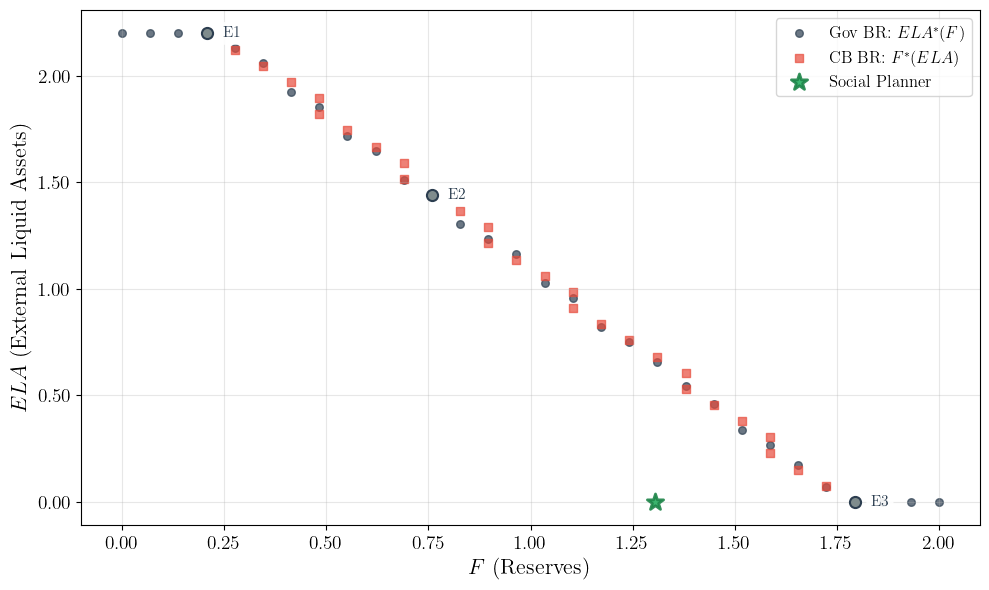

Found equilibria (F, DLA, B*, distance):
Computing utility and theta at each equilibrium...

E1: F = 0.206897, DLA = 2.200000, B* = 2.000000, U = -0.317679, theta = 0.691605, dist = 0.000000e+00, prob = 0.033333
E2: F = 0.758621, DLA = 1.441379, B* = 1.241379, U = -0.309810, theta = 0.698585, dist = 0.000000e+00, prob = 0.033333
E3: F = 1.793103, DLA = 0.000000, B* = 0.000000, U = -0.294348, theta = 0.703779, dist = 0.000000e+00, prob = 0.000000
E2: F = 0.758621, DLA = 1.441379, B* = 1.241379, U = -0.309810, theta = 0.698585, dist = 0.000000e+00, prob = 0.033333
E3: F = 1.793103, DLA = 0.000000, B* = 0.000000, U = -0.294348, theta = 0.703779, dist = 0.000000e+00, prob = 0.000000

Social Planner Optimum: F = 1.303448, DLA = 0.000000, B* = 1.103448, U = -0.280590, theta = 0.613179, prob = 0.300000
Social Planner DLA (full precision): 0.000000000000000000

Social Planner Optimum: F = 1.303448, DLA = 0.000000, B* = 1.103448, U = -0.280590, theta = 0.613179, prob = 0.300000
Social Planner D

In [66]:
# Plotting multiple equilibria

# Plot best response functions: Government's DLA*(F) and CB's F*(DLA)
fig, ax = plt.subplots(figsize=(10, 6))

# Convert to numpy (easier local-min search)
Fvals = np.asarray(results["Fvals"])
DLAstar = np.asarray(results["DLAstar"])
FstarCB = np.asarray(results["FstarCB"])
Bstar = np.asarray(results["Bstar"])
DLACB = np.asarray(results["DLACB"])

# Plot government BR: DLA*(F) (F on x, DLA on y)
ax.scatter(Fvals, DLAstar, color="#2C3E50", s=30, alpha=0.7, marker='o', label='Gov BR: $ELA^*(F)$')

# Plot central bank BR: we want points (F*(DLA), DLA) so swap axes when plotting
ax.scatter(FstarCB, DLACB, color="#E74C3C", s=30, alpha=0.7, marker='s', label='CB BR: $F^*(ELA)$')

# Add Social Planner's equilibrium
nash_sp_f = float(results["Fgraph"])
nash_sp_dla = float(results["Tgraph"])
nash_sp_b = float(results["Bgraph"]) 
ax.scatter(nash_sp_f, nash_sp_dla, color='#27AE60', s=150, alpha=0.9, marker='*', 
           edgecolors='#1E8449', linewidth=2, label='Social Planner', zorder=6)

# Distance matrix between the two curves (all pairs)
dF = Fvals[:, None] - FstarCB[None, :]
dD = DLAstar[:, None] - DLACB[None, :]
dist = np.sqrt(dF**2 + dD**2)

# Tolerance: relative to ranges
range_F = max(Fvals.max() - Fvals.min(), 1e-8)
range_D = max(DLAstar.max() - DLAstar.min(), 1e-8)
tol = 1e-3 * max(range_F, range_D)

# Find local minima in dist matrix that are below tolerance
intersections = []
rows, cols = dist.shape
for i in range(rows):
    for j in range(cols):
        # neighborhood bounds
        i0 = max(0, i - 1)
        i1 = min(rows, i + 2)
        j0 = max(0, j - 1)
        j1 = min(cols, j + 2)
        local_min = dist[i, j] <= dist[i0:i1, j0:j1].min()
        if local_min and dist[i, j] <= tol:
            intersections.append((i, j, float(dist[i, j])))

# Fallback: if no intersections found with strict tol, pick a few smallest distances
if len(intersections) == 0:
    flat_idx = np.argsort(dist.ravel())[:5]  # take up to 5 closest pairs
    for idx in flat_idx:
        i = idx // cols
        j = idx % cols
        intersections.append((i, j, float(dist[i, j])))

# Reduce duplicates (in case nearby indices both selected) by clustering
accepted = []
seen = set()
for (i, j, dval) in intersections:
    # cluster radius in index-space
    key = None
    duplicate = False
    for (ai, aj, _) in accepted:
        if abs(ai - i) <= 1 and abs(aj - j) <= 1:
            duplicate = True
            break
    if not duplicate:
        accepted.append((i, j, dval))

# Plot and annotate all equilibria found
equilibria = []
for k, (i, j, dval) in enumerate(accepted, start=1):
    f_gov = Fvals[i]
    dla_gov = DLAstar[i]
    b_gov = Bstar[i]
    f_cb = FstarCB[j]
    dla_cb = DLACB[j]

    # Use midpoint for plotting a representative equilibrium coordinate
    nash_f = float((f_gov + f_cb) / 2.0)
    nash_dla = float((dla_gov + dla_cb) / 2.0)
    nash_b = float(b_gov)
    equilibria.append((nash_f, nash_dla, nash_b, dval))

    ax.plot(nash_f, nash_dla, 'o', color='#7F8C8D', markersize=8, markeredgecolor='#2C3E50', markeredgewidth=1.5, zorder=5)
    # Calculate offset for text (about 2% of x-axis range)
    x_offset = (Fvals.max() - Fvals.min()) * 0.02
    ax.text(nash_f + x_offset, nash_dla, f'E{k}', fontsize=11, color='#2C3E50', va='center', ha='left', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.9))

# If no equilibria detected (shouldn't happen because of fallback), fall back to nearest-point
if len(equilibria) == 0:
    print("No equilibria detected within tolerance; falling back to nearest-point.")
    idx = np.argmin(dist)
    i = idx // cols
    j = idx % cols
    nash_f = float((Fvals[i] + FstarCB[j]) / 2.0)
    ax.plot(nash_f, nash_dla, 'o', color='#7F8C8D', markersize=8, markeredgecolor='#2C3E50', markeredgewidth=1.5, zorder=5)
    # Calculate offset for text (about 2% of x-axis range)
    x_offset = (Fvals.max() - Fvals.min()) * 0.02
    ax.text(nash_f + x_offset, nash_dla, 'E1', fontsize=11, color='#2C3E50', va='center', ha='left', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.9))

# Legend + formatting
ax.set_xlabel('$F$ (Reserves)', fontsize=16)
ax.set_ylabel('$ELA$ (External Liquid Assets)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=12, loc='best')
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/equilibria.png', dpi=300, bbox_inches='tight')
plt.show()

print('Found equilibria (F, DLA, B*, distance):')
print('Computing utility and theta at each equilibrium...\n')

# Store results for table
equilibria_results = []

for k, (f_e, d_e, b_e, dval) in enumerate(equilibria, start=1):
    # Set up fiscal parameters for this equilibrium: (B, DLA, s1)
    # s1 = 0 based on the fiscal_params used in the analysis
    fiscal_eq = (b_e, d_e, 0.0)
    
    # Compute decentralized equilibrium at this point
    grids, _ = decentralized_equilibrium(fiscal_eq, f_e, model, max_iter=1_000, tol=1e-10)
        #grids   = (Chat, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U, θhat)

    # Extract utility (first element of XX_eq) and theta (first element of YY_eq)
    U_eq = float(grids[10])
    theta_eq = float(grids[11])
    # Print \theta as probability of crisis instead where \theta is a random variable with uniform distribution and the probability of crisis is P(\theta_eq > \theta)
    
    prob = jnp.sum(model.Π[model.θ_grid > theta_eq])
    
    print(f'E{k}: F = {f_e:.6f}, DLA = {d_e:.6f}, B* = {b_e:.6f}, U = {U_eq:.6f}, theta = {theta_eq:.6f}, dist = {dval:.6e}, prob = {prob:.6f}')
    
    # Store for table
    equilibria_results.append({
        'label': f'E{k}',
        'F': f_e,
        'DLA': d_e,
        'B': b_e,
        'U': U_eq,
        'theta': theta_eq,
        'prob': float(prob)
    })
    
    
#def centequilibrium_fast(fiscal, reserves, model, max_iter=1_000, tol=1e-10):
#grids   = (Chat, R1, Ls, Is, Ks, Qs, Xs, Cs, ECs, ERs, U, θhat)

gridsSP, _ = decentralized_equilibrium((nash_sp_b, 0.0, 0.0), nash_sp_f, model, max_iter=1_000, tol=1e-10)
U_sp = float(gridsSP[10])
theta_sp = float(gridsSP[11])
prob_sp = jnp.sum(model.Π[model.θ_grid > theta_sp])

print(f'\nSocial Planner Optimum: F = {nash_sp_f:.6f}, DLA = {nash_sp_dla:.6f}, B* = {nash_sp_b:.6f}, U = {U_sp:.6f}, theta = {theta_sp:.6f}, prob = {prob_sp:.6f}')

# Add Social Planner to results
equilibria_results.append({
    'label': 'SP',
    'F': nash_sp_f,
    'DLA': nash_sp_dla,
    'B': nash_sp_b,
    'U': U_sp,
    'theta': theta_sp,
    'prob': float(prob_sp)
})

# print nash_sp_dla with all decimal places
print(f'Social Planner DLA (full precision): {nash_sp_dla:.18f}')


In [55]:


# Create LaTeX table
print('\n' + '='*80)
print('LaTeX Table:')
print('='*80 + '\n')

latex_table = r'''\begin{table}[htbp]
\centering
\caption{Equilibrium Outcomes: Nash vs. Social Planner}
\label{tab:equilibria}
\begin{tabular}{lcccccc}
\hline\hline
Equilibrium & $F$ & $DLA$ & $B^*$ & $U$ & $\theta^*$ & Crisis Prob. \\
 & (Reserves) & (Liquid Assets) & (Debt) & (Utility) & (Threshold) & $P(\theta>\theta^*)$ \\
\hline
'''

# Add each equilibrium to the table
for result in equilibria_results:
    label = result['label']
    if label == 'SP':
        latex_table += r'\hline' + '\n'
        label = 'Social Planner'
    
    latex_table += f"{label} & {result['F']:.4f} & {result['DLA']:.4f} & {result['B']:.4f} & {result['U']:.4f} & {result['theta']:.4f} & {result['prob']:.4f} \\\\\n"

latex_table += r'''\hline\hline
\end{tabular}
\end{table}'''

print(latex_table)

# Save to file
with open('Tables/tab_equilibria.tex', 'w') as f:
    f.write(latex_table)
    
print('\n' + '='*80)
print('Table saved to: Tables/tab_equilibria.tex')
print('='*80)




LaTeX Table:

\begin{table}[htbp]
\centering
\caption{Equilibrium Outcomes: Nash vs. Social Planner}
\label{tab:equilibria}
\begin{tabular}{lcccccc}
\hline\hline
Equilibrium & $F$ & $DLA$ & $B^*$ & $U$ & $\theta^*$ & Crisis Prob. \\
 & (Reserves) & (Liquid Assets) & (Debt) & (Utility) & (Threshold) & $P(\theta>\theta^*)$ \\
\hline
E1 & 0.2069 & 2.2000 & 2.0000 & -0.3177 & 0.6916 & 0.0333 \\
E2 & 0.7586 & 1.4414 & 1.2414 & -0.3098 & 0.6986 & 0.0333 \\
E3 & 1.7931 & 0.0000 & 0.0000 & -0.2981 & 0.7038 & 0.0000 \\
\hline
Social Planner & 1.3034 & 0.0000 & 1.1034 & 54018353986712624.0000 & 0.4973 & 0.6667 \\
\hline\hline
\end{tabular}
\end{table}

Table saved to: Tables/tab_equilibria.tex


In [56]:
#     return (C0star, Uhat, Spread, L_arr, K_arr, Q_arr, X_arr, C2_arr, EC, ER, DLA_grid, diagnostics)

def gov_utility_for_fixed_reserves(F_value, fiscal_params, model):
    """
    Compute government's decentralized solution for all DLA values at a fixed reserves level F.
    
    Parameters:
        F_value: Fixed reserves level (scalar)
        fiscal_params: Tuple (B, s1) for debt and transfers
        model: Model namedtuple with parameters
    
    Returns:
        DLA_grid: Array of DLA values
        Uhat: Array of utility values for each DLA
        diagnostics: Convergence information
    """
    # Call decentralizedgov_model with fixed reserves
    results = decentralizedgov_model(fiscal_params, F_value, model)
    
    # Extract DLA grid (index 10) and utility (index 1)
    DLA_grid = results[10]
    Uhat = results[1]
    C0 = results[0]
    EC = results[8]
    diagnostics = results[11]
    
    return DLA_grid, Uhat, diagnostics, C0, EC

Computing utility for F = 0.0...
  Optimal DLA* = 2.5379, U = 3.760800

Computing utility for F = 1.0...
  Optimal DLA* = 2.5379, U = 3.760800

Computing utility for F = 1.0...
  Optimal DLA* = 1.1034, U = 3.778126

Computing utility for F = 1.5...
  Optimal DLA* = 1.1034, U = 3.778126

Computing utility for F = 1.5...
  Optimal DLA* = 0.3310, U = 3.786340

Computing utility for F = 2.0...
  Optimal DLA* = 0.3310, U = 3.786340

Computing utility for F = 2.0...
  Optimal DLA* = 0.0000, U = 3.782317

  Optimal DLA* = 0.0000, U = 3.782317



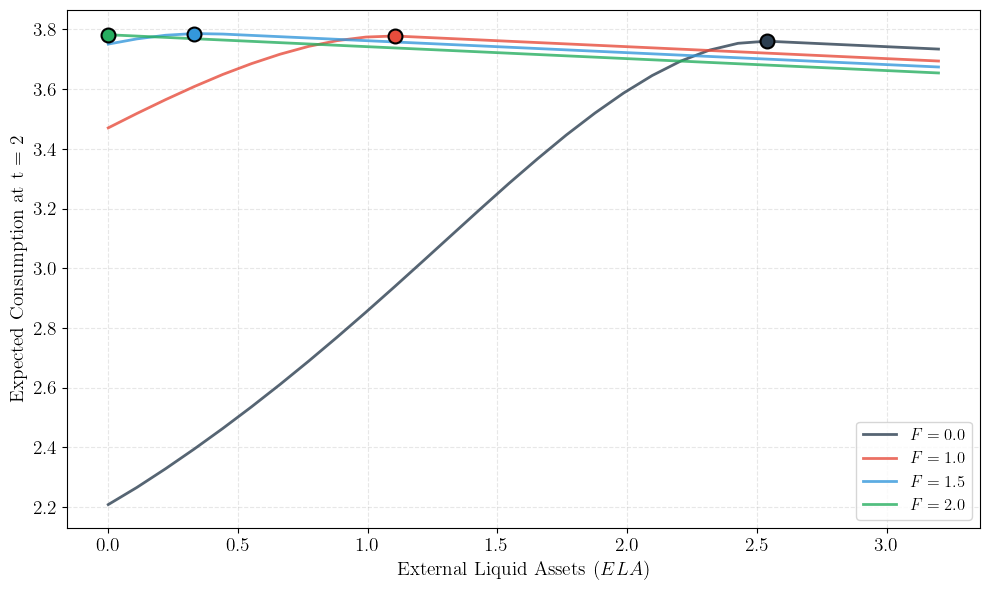

In [57]:
model = create_model(A=0.2, θgrid=30, Bgrid=30, Fgrid=30, Sgrid=30, B_h=5.0, F_h=2.0, τ=0.04, τg=0.04, τlt=0.04)


# Plot government's utility function for different reserve levels
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6))

# Define fiscal parameters: (B, s1)
fiscal_params = (3.0, 0.0)

# Define reserve levels to plot
F_levels = [0.0, 1.0, 1.5, 2.0]
colors = ['#2C3E50', '#E74C3C', '#3498DB', '#27AE60']

for F_val, color in zip(F_levels, colors):
    print(f"Computing utility for F = {F_val}...")
    DLA_grid, Uhat, diagnostics, Chat, ECstar = gov_utility_for_fixed_reserves(F_val, fiscal_params, model)
    
    # Check for convergence issues
    if diagnostics['n_failed_convergence'] > 0:
        print(f"  ⚠️  {diagnostics['n_failed_convergence']} points failed to converge")
    if diagnostics['n_negative_consumption'] > 0:
        print(f"  ⚠️  {diagnostics['n_negative_consumption']} points have negative consumption")
    
    # Find optimal DLA (maximum utility)
    optimal_idx = jnp.argmax(Uhat)
    optimal_DLA = DLA_grid[optimal_idx]
    optimal_U = Uhat[optimal_idx]
    optimal_C0 = Chat[optimal_idx]
    optimal_EC = ECstar[optimal_idx]
    
    # Plot utility curve
    ax.plot(DLA_grid, ECstar, color=color, linewidth=2, alpha=0.8, label=f'$F = {F_val}$')
    
    # Mark optimal point
    ax.scatter([optimal_DLA], [optimal_EC], color=color, s=100, zorder=5, 
               edgecolors='black', linewidths=1.5)
    
    print(f"  Optimal DLA* = {optimal_DLA:.4f}, U = {optimal_EC:.6f}\n")

ax.set_xlabel(r'External Liquid Assets ($ELA$)', fontsize=14)
ax.set_ylabel(r'Expected Consumption at t = 2', fontsize=14)
#ax.set_title(r'Government Utility Function for Different Reserve Levels', fontsize=14)
ax.legend(loc='best', frameon=True, fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()

plt.savefig('Figures/utility_by_ELA.png', dpi=300, bbox_inches='tight')
plt.show()

Computing C0 for F = 0.0...
  Optimal DLA* = 2.5379, C0* = 1.025978

Computing C0 for F = 0.5...
  Optimal DLA* = 1.7655, C0* = 1.025683

Computing C0 for F = 1.0...
  Optimal DLA* = 1.1034, C0* = 1.025974

Computing C0 for F = 1.5...
  Optimal DLA* = 1.7655, C0* = 1.025683

Computing C0 for F = 1.0...
  Optimal DLA* = 1.1034, C0* = 1.025974

Computing C0 for F = 1.5...
  Optimal DLA* = 0.3310, C0* = 1.025708

  Optimal DLA* = 0.3310, C0* = 1.025708



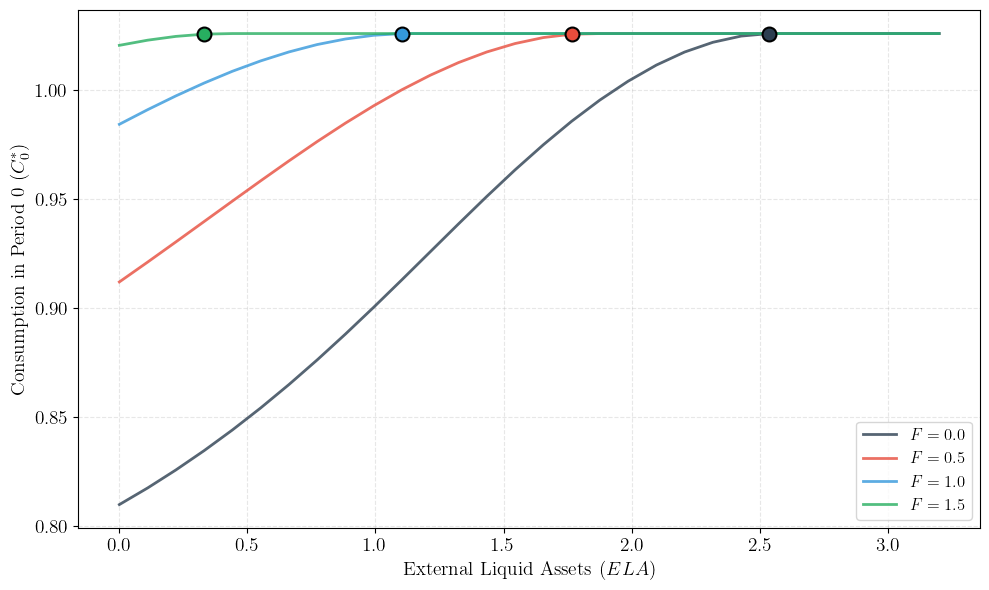

In [58]:
# Plot government's C0star (period 0 consumption) for different reserve levels
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6))

# Define fiscal parameters: (B, s1)
fiscal_params = (3.0, 0.0)

# Define reserve levels to plot
F_levels = [0.0, 0.5, 1.0, 1.5]
colors = ['#2C3E50', '#E74C3C', '#3498DB', '#27AE60']

for F_val, color in zip(F_levels, colors):
    print(f"Computing C0 for F = {F_val}...")
    DLA_grid, Uhat, diagnostics, C0star, ECstar = gov_utility_for_fixed_reserves(F_val, fiscal_params, model)
    
    # Check for convergence issues
    if diagnostics['n_failed_convergence'] > 0:
        print(f"  ⚠️  {diagnostics['n_failed_convergence']} points failed to converge")
    if diagnostics['n_negative_consumption'] > 0:
        print(f"  ⚠️  {diagnostics['n_negative_consumption']} points have negative consumption")
    
    # Find optimal DLA (maximum utility)
    optimal_idx = jnp.argmax(Uhat)
    optimal_DLA = DLA_grid[optimal_idx]
    optimal_C0 = C0star[optimal_idx]
    optimal_EC = ECstar[optimal_idx]
    
    # Plot C0 curve
    ax.plot(DLA_grid, C0star, color=color, linewidth=2, alpha=0.8, label=f'$F = {F_val}$')
    
    # Mark optimal point
    ax.scatter([optimal_DLA], [optimal_C0], color=color, s=100, zorder=5, 
               edgecolors='black', linewidths=1.5)
    
    print(f"  Optimal DLA* = {optimal_DLA:.4f}, C0* = {optimal_C0:.6f}\n")

ax.set_xlabel(r'External Liquid Assets ($ELA$)', fontsize=14)
ax.set_ylabel(r'Consumption in Period 0 ($C_0^*$)', fontsize=14)
#ax.set_title(r'Period 0 Consumption for Different Reserve Levels', fontsize=14)
ax.legend(loc='best', frameon=True, fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.savefig('Figures/c0_by_ELA.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
print(C0star)

[1.02056951 1.02293543 1.02467744 1.02570753 1.02597835 1.02597835
 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835
 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835
 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835
 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835 1.02597835]


In [60]:
print("F_levels:", F_levels)
print("Length of F_levels:", len(F_levels))
print("Colors:", colors)
print("Length of colors:", len(colors))

F_levels: [0.0, 0.5, 1.0, 1.5]
Length of F_levels: 4
Colors: ['#2C3E50', '#E74C3C', '#3498DB', '#27AE60']
Length of colors: 4
